# polars

= pandas plus rapide écris en rust

In [2]:
import polars as pl

In [3]:
df = pl.read_csv('./data/dataset_titanic.csv')
df

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
i64,i64,i64,str,str,f64,i64,i64,str,f64,str,str
1,0,3,"""Braund, Mr. Owen Harris""","""male""",22.0,1,0,"""A/5 21171""",7.25,null,"""S"""
2,1,1,"""Cumings, Mrs. John Bradley (Fl…","""female""",38.0,1,0,"""PC 17599""",71.2833,"""C85""","""C"""
3,1,3,"""Heikkinen, Miss. Laina""","""female""",26.0,0,0,"""STON/O2. 3101282""",7.925,null,"""S"""
4,1,1,"""Futrelle, Mrs. Jacques Heath (…","""female""",35.0,1,0,"""113803""",53.1,"""C123""","""S"""
5,0,3,"""Allen, Mr. William Henry""","""male""",35.0,0,0,"""373450""",8.05,null,"""S"""
…,…,…,…,…,…,…,…,…,…,…,…
887,0,2,"""Montvila, Rev. Juozas""","""male""",27.0,0,0,"""211536""",13.0,null,"""S"""
888,1,1,"""Graham, Miss. Margaret Edith""","""female""",19.0,0,0,"""112053""",30.0,"""B42""","""S"""
889,0,3,"""Johnston, Miss. Catherine Hele…","""female""",null,1,2,"""W./C. 6607""",23.45,null,"""S"""


In [11]:
df.group_by('Pclass').mean().select('Pclass', 'Survived').sort('Pclass')

Pclass,Survived
i64,f64
1,0.62963
2,0.472826
3,0.242363


In [15]:
df.group_by('Embarked', 'Pclass').mean().select('Pclass', 'Embarked', 'Survived').sort('Pclass')

Pclass,Embarked,Survived
i64,str,f64
1,"""C""",0.694118
1,"""S""",0.582677
1,null,1.0
1,"""Q""",0.5
2,"""C""",0.529412
2,"""S""",0.463415
2,"""Q""",0.666667
3,"""Q""",0.375
3,"""C""",0.378788


In [16]:
df.filter(pl.col("Age") > 25)

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
i64,i64,i64,str,str,f64,i64,i64,str,f64,str,str
2,1,1,"""Cumings, Mrs. John Bradley (Fl…","""female""",38.0,1,0,"""PC 17599""",71.2833,"""C85""","""C"""
3,1,3,"""Heikkinen, Miss. Laina""","""female""",26.0,0,0,"""STON/O2. 3101282""",7.925,null,"""S"""
4,1,1,"""Futrelle, Mrs. Jacques Heath (…","""female""",35.0,1,0,"""113803""",53.1,"""C123""","""S"""
5,0,3,"""Allen, Mr. William Henry""","""male""",35.0,0,0,"""373450""",8.05,null,"""S"""
7,0,1,"""McCarthy, Mr. Timothy J""","""male""",54.0,0,0,"""17463""",51.8625,"""E46""","""S"""
…,…,…,…,…,…,…,…,…,…,…,…
884,0,2,"""Banfield, Mr. Frederick James""","""male""",28.0,0,0,"""C.A./SOTON 34068""",10.5,null,"""S"""
886,0,3,"""Rice, Mrs. William (Margaret N…","""female""",39.0,0,5,"""382652""",29.125,null,"""Q"""
887,0,2,"""Montvila, Rev. Juozas""","""male""",27.0,0,0,"""211536""",13.0,null,"""S"""


In [ ]:
lazy_read = pl.scan_csv("./data/dataset_titanic.csv")
lazy_read

In [24]:
res = pl.scan_csv("./data/dataset_titanic.csv").group_by('Embarked', 'Pclass').mean().select('Pclass', 'Embarked', 'Survived').sort('Pclass')
res

In [25]:
df = res.collect()
df

Pclass,Embarked,Survived
i64,str,f64
1,"""Q""",0.5
1,null,1.0
1,"""S""",0.582677
1,"""C""",0.694118
2,"""C""",0.529412
2,"""S""",0.463415
2,"""Q""",0.666667
3,"""Q""",0.375
3,"""C""",0.378788


## lazy query 

il y a un phase d'optimisation avec des graph and simplification de graph.

In [35]:
q = (
    pl.scan_csv("./data/dataset_titanic.csv")
    .filter(pl.col("Age") > 20)
    .group_by("Sex", "Pclass")
    .agg(pl.all().mean())
    .select('Sex', 'Pclass', 'Survived', 'Age')
)
q


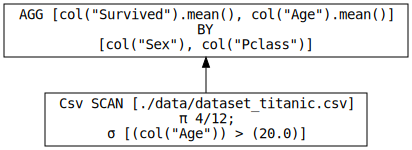

In [36]:
q.show_graph()

In [37]:
df = q.collect()
df

Sex,Pclass,Survived,Age
str,i64,f64,f64
"""female""",1,0.971831,38.28169
"""male""",2,0.0625,35.5375
"""female""",3,0.418182,30.936364
"""female""",2,0.896552,33.646552
"""male""",3,0.129944,31.898305
"""male""",1,0.382979,43.409574
